# Rashevsky (1937): An Early Dynamical Model of Conditioning

This notebook accompanies **N. Rashevsky, "Mathematical Biophysics of Conditioning" (1937)**  [link](https://link.springer.com/article/10.1007/BF02288396)

The goal is **not** to study a modern trainable neural network, but to explore one of the earliest mathematical models of a small neural circuit. Rashevsky proposes a dynamical model with:
- **thresholds**
- **saturation**
- **excitation and inhibition**
- **recurrent feedback**
- **memory through persistent activity**

The central idea is that **conditioning** can be explained as a change of state in a recurrent neural circuit, rather than as a special extra "conditioning mechanism". In the paper, Rashevsky explicitly argues that conditioning should be understood as a case of **physical hysteresis**.


## What is conditioning?

In **classical conditioning**, a stimulus that initially does not trigger a response can acquire that ability through repeated association with another stimulus.

Classic example:

- food naturally causes salivation,
- a bell initially does not,
- after repeated pairings of bell + food,
- the bell alone can trigger salivation.

In Rashevsky's setting, the question is:

> **How can a nervous system physically change so that a previously neutral stimulus starts producing a response?**

His proposed answer is: a recurrent excitatory circuit can be pushed into a new persistent state, and that state change can later allow the conditioned stimulus to trigger the response.


## What does the paper try to do?

Rashevsky describes this work as part of a program of **mathematical biophysics in psychology**. The idea is to explain psychological phenomena using simplified biophysical assumptions about nerve fibers and synapses, written as mathematical equations. He states that the aim is to derive the important features of conditioning from more basic postulates, rather than introducing a special conditioning mechanism by hand.

So this paper is much closer to:

- **theoretical neuroscience**
- **mathematical biology**
- **dynamical systems**

than to modern machine learning.


## How the model works

The paper builds up the model in stages.

#### 1. A stimulus produces neural excitation
A continuous physiological stimulus produces a **train of impulses**, and Rashevsky defines an excitation intensity ($E$) based on the frequency of those impulses. For moderate input, excitation grows with stimulus strength, but due to refractoriness it cannot grow forever and instead **saturates**.

#### 2. Excitatory and inhibitory quantities evolve over time
At a synapse or fiber ending, Rashevsky introduces:

- an **excitatory quantity** ($e$),
- an **inhibitory quantity** ($j$).

These do not stay constant: they **build up** under stimulation and **decay** over time. Later in the paper he explicitly refers back to equations (7) and (8) as the equations governing how ($e$) and ($j$) vary under stimulation. fileciteturn9file4

#### 3. Neighboring fibers respond only above threshold
A connection only becomes active when excitation is strong enough relative to inhibition. This creates a **thresholded nonlinear system**.

#### 4. Recurrent excitation can create persistent activity
In the central circuit of **Figure 1**, two neurons excite each other. Rashevsky explains that if the initial excitation is too small, activity dies out. But if it is large enough, the two neurons can keep each other active, so that the system remains excited even after the original external input is removed.


## Figure 1: the core recurrent circuit

The most important mathematical object in the paper is the **2-neuron recurrent loop** from Figure 1.

Rashevsky considers two neurons (or fibers), often denoted ($I$) and ($II$), arranged so that each excites the other. He then derives a pair of coupled nonlinear differential equations for the corresponding state variables $e_1(t)$ and $e_2(t)$. These equations are given in **equation (11)**. He also notes that the nonlinear system does not have a known analytic solution, and therefore studies it graphically.

This is exactly why numerical simulation is a natural modern way to study the model.


## Why this is interesting

Although the paper is old, several ideas feel surprisingly modern:

- nonlinear activation
- recurrent feedback
- stable and unstable states
- memory through persistent activity
- state transitions caused by crossing a threshold

In modern language, the Figure 1 system can be viewed as a very small **continuous-time recurrent dynamical system**. In some parameter regimes it behaves like a **bistable** system: one stable state corresponds to rest, another to persistent activity. Rashevsky's graphical discussion of Figures 2 and 3 is essentially about how the qualitative behavior changes with parameter values.


## Figures 2 and 3: two qualitative regimes

A major goal of this notebook will be to reproduce the two main qualitative cases discussed in the paper.

Rashevsky explains that:

- in one regime, the circuit can sustain a nonzero active state,
- in the other regime, the only stable state is the quiescent state ($e_1=e_2=0$).

He explicitly says that whether we obtain the case of Figure 2 or the case of Figure 3 depends on the numerical values of the constants in the equations.

This makes the paper ideal for a computational exercise: we can simulate the same equations for different parameter choices and visualize the resulting trajectories.


## Physical hysteresis

A central term in the paper is **physical hysteresis**.

A hysteretic system has a form of **memory**: the current state is not determined only by the current input, but also by the system's past. In Rashevsky's model, the same present stimulus can produce different outcomes depending on whether the recurrent circuit is still in its resting state or has previously been pushed into a self-sustaining excited state. Rashevsky explicitly presents conditioning as a complex case of ordinary physical hysteresis.

For this notebook, the key intuition is:

- a small perturbation may die out,
- a large enough perturbation may push the system across a threshold,
- after crossing that threshold, the system may remain active.


## How this differs from modern neural networks

It is important not to confuse this paper with modern deep learning.

This paper does **not** propose:

- large trainable networks,
- a dataset-driven learning procedure,
- backpropagation,
- weight optimization.

Instead, it proposes a **hand-designed dynamical model**. We choose the structure of the circuit and the values of the parameters, then study how the system evolves over time. The main questions are about:

- stability,
- thresholds,
- recurrent amplification,
- persistence,
- inhibition,
- qualitative dynamical behavior.

So the "use" of the model is:

1. define the equations,
2. choose parameter values,
3. integrate the ODEs numerically,
4. analyze trajectories, equilibria, and phase portraits.


## A practical note on notation

The original notation in the paper is historically interesting, but not always convenient for programming. In the coding exercises we may therefore use a slightly cleaner notation, while keeping the same qualitative structure:

- thresholds,
- saturating excitation,
- decay terms,
- coupling between two units.

This means our implementation should be understood as a **computational version of Rashevsky's model**, not as an attempt to reproduce every symbol from the paper literally.


## Exercise preview

Before coding, make sure you understand the following conceptual questions:

1. Why can mutual excitation create persistent activity?
2. Why does saturation matter?
3. Why can the same system either die out or stay active depending on parameter values?
4. Why is this an example of hysteresis?
5. In what sense is this an early "neural network", and in what sense is it *not* like modern neural networks?

We now move on to the implementation.


In [ ]:
# Imports for the exercises
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

## From paper to computation

We will use a simple symmetric version of the Figure 1 model.

Let:

- `e1(t)` be the excitatory state associated with neuron 1,
- `e2(t)` be the excitatory state associated with neuron 2.

Each state:

- **decays** over time,
- is **driven** by the other neuron's excitation,
- uses a **thresholded saturating nonlinearity**.

A convenient implementation is:

$$
\dot e_1 = A \, E(e_2; \alpha, h_2) - e_1,
\qquad
\dot e_2 = A \, E(e_1; \alpha, h_1) - e_2,
$$

where

$$
E(x; \alpha, h)=
\begin{cases}
1-e^{-\alpha(x-h)}, & x>h \\
0, & x\le h.
\end{cases}
$$

This captures the key qualitative ingredients from the paper:

- no activation below threshold,
- increasing activation above threshold,
- saturation for large activation,
- recurrent amplification through the other unit.


In [ ]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint


## Exercise 1 — Implement the saturating excitation function

**Task.** Implement a thresholded saturating nonlinearity `excitation(x, alpha, h)`.

Requirements:

- return `0` when `x <= h`,
- otherwise return the saturating expression above,
- support both scalars and NumPy arrays.

### Solution


In [ ]:

def excitation(x, alpha, h):
    x = np.asarray(x)
    y = np.zeros_like(x, dtype=float)

    mask = x > h
    y[mask] = 1.0 - np.exp(-alpha * (x[mask] - h))

    # return a scalar if the input was scalar
    if y.ndim == 0:
        return float(y)
    return y


Let's quickly inspect the shape of this nonlinearity.


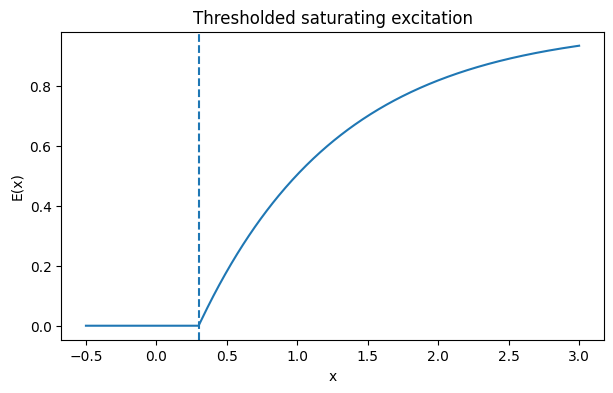

In [ ]:

x = np.linspace(-0.5, 3.0, 500)
y = excitation(x, alpha=1.0, h=0.3)

plt.figure(figsize=(7, 4))
plt.plot(x, y)
plt.axvline(0.3, linestyle="--")
plt.xlabel("x")
plt.ylabel("E(x)")
plt.title("Thresholded saturating excitation")
plt.show()


## Exercise 2 — Implement the 2-neuron recurrent loop

**Task.** Implement the ODE system for the Figure 1-style excitatory loop.

Use a parameter dictionary with the following keys:

- `A`
- `alpha`
- `h1`, `h2`

### Solution


In [ ]:

def rashevsky_rhs(state, t, params):
    e1, e2 = state

    E1 = excitation(e1, alpha=params["alpha"], h=params["h1"])
    E2 = excitation(e2, alpha=params["alpha"], h=params["h2"])

    de1dt = params["A"] * E2 - e1
    de2dt = params["A"] * E1 - e2
    return [de1dt, de2dt]


We also define a helper to simulate the system.


In [ ]:

def simulate_rashevsky(x0, t, params):
    return odeint(rashevsky_rhs, x0, t, args=(params,))


## Exercise 3 — Run a first simulation

**Task.** Choose a parameter setting and initial condition, simulate the system, and plot `e1(t)` and `e2(t)`.

### Solution


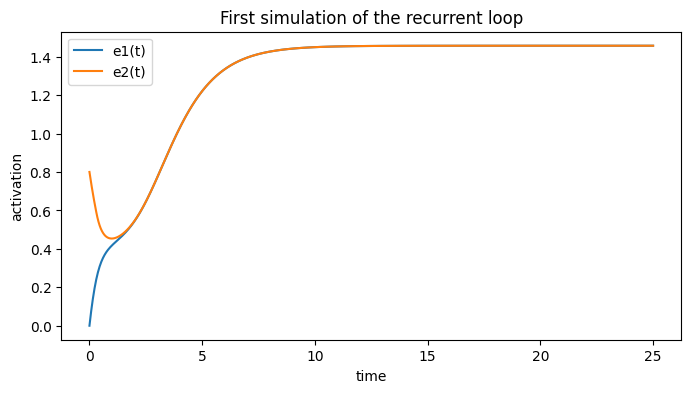

In [ ]:

params_base = {
    "A": 1.6,
    "alpha": 2.0,
    "h1": 0.25, "h2": 0.25,
}

t = np.linspace(0, 25, 1000)
x0 = [0.0, 0.8]

sol = simulate_rashevsky(x0, t, params_base)

plt.figure(figsize=(8, 4))
plt.plot(t, sol[:, 0], label="e1(t)")
plt.plot(t, sol[:, 1], label="e2(t)")
plt.xlabel("time")
plt.ylabel("activation")
plt.title("First simulation of the recurrent loop")
plt.legend()
plt.show()


## Exercise 4 — Study sensitivity to the initial condition

A central theme in the paper is that the same system can behave differently depending on whether the initial perturbation is strong enough to cross a threshold.

**Task.** Simulate the same parameter setting for several initial conditions and compare trajectories.

### Solution


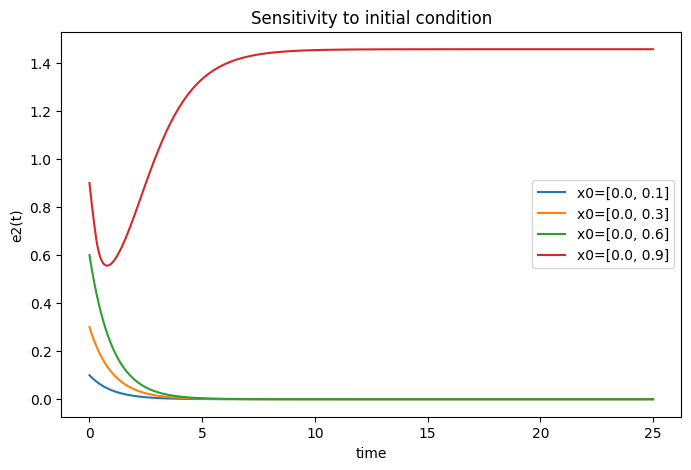

In [ ]:

initial_conditions = [
    [0.0, 0.1],
    [0.0, 0.3],
    [0.0, 0.6],
    [0.0, 0.9],
]

plt.figure(figsize=(8, 5))
for x0 in initial_conditions:
    sol = simulate_rashevsky(x0, t, params_base)
    label = f"x0={x0}"
    plt.plot(t, sol[:, 1], label=label)

plt.xlabel("time")
plt.ylabel("e2(t)")
plt.title("Sensitivity to initial condition")
plt.legend()
plt.show()


### Interpretation

When the initial perturbation is too small, activity may decay back to zero.  
When it is large enough, recurrent amplification can sustain a nonzero level of activity.

That is the key hysteresis-like intuition in the paper.


## Exercise 5 — Reproduce two qualitative regimes

The paper discusses two important qualitative cases:

- a regime where the system can sustain nonzero activity,
- a regime where activity always dies out.

We now build two parameter sets:

- `params_persistent`: persistent activity is possible,
- `params_quiescent`: trajectories return to zero.

### Solution


In [ ]:

params_persistent = {
    "A": 1.0,
    "alpha": 4.0,
    "h1": 0.30, "h2": 0.30,
}

params_quiescent = {
    "A": 1.0,
    "alpha": 4.0,
    "h1": 0.50, "h2": 0.50,
}


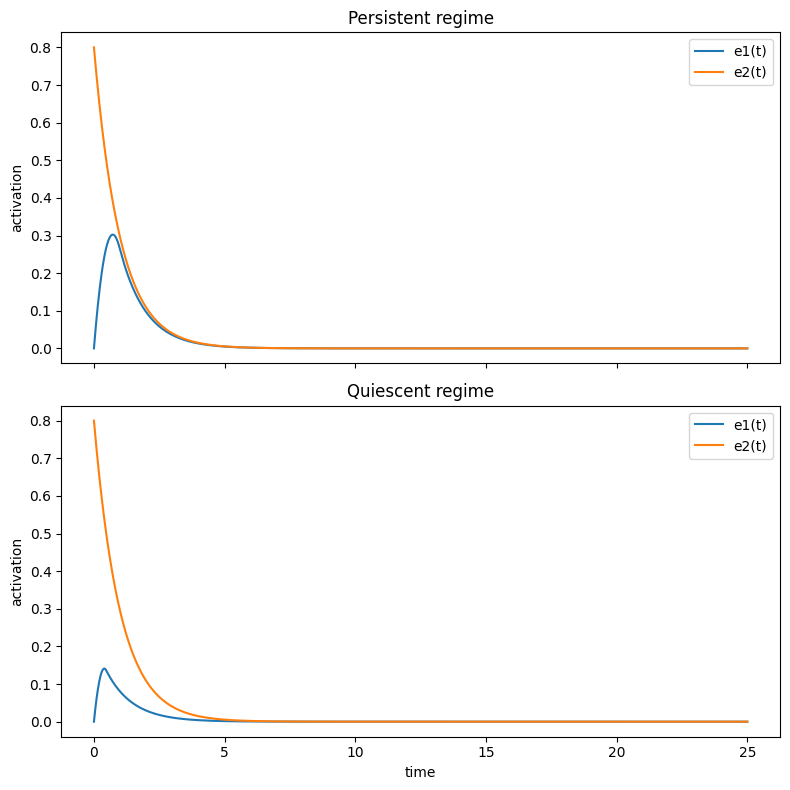

In [ ]:

def plot_time_series_comparison(params_list, names, x0=(0.0, 0.8), t=np.linspace(0, 25, 1000)):
    fig, axes = plt.subplots(len(params_list), 1, figsize=(8, 4 * len(params_list)), sharex=True)
    if len(params_list) == 1:
        axes = [axes]

    for ax, params, name in zip(axes, params_list, names):
        sol = simulate_rashevsky(x0, t, params)
        ax.plot(t, sol[:, 0], label="e1(t)")
        ax.plot(t, sol[:, 1], label="e2(t)")
        ax.set_title(name)
        ax.set_ylabel("activation")
        ax.legend()

    axes[-1].set_xlabel("time")
    plt.tight_layout()
    plt.show()

plot_time_series_comparison(
    [params_persistent, params_quiescent],
    ["Persistent regime", "Quiescent regime"],
)


## Exercise 6 — Plot trajectories for many initial conditions

**Task.** For each regime, simulate many initial conditions and compare the long-term behavior.

### Solution


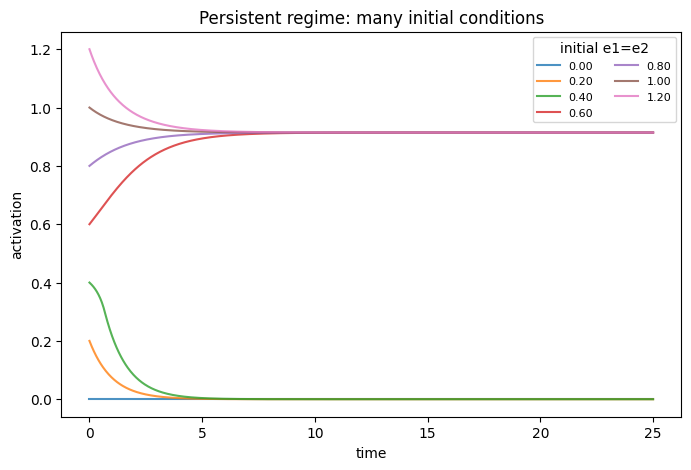

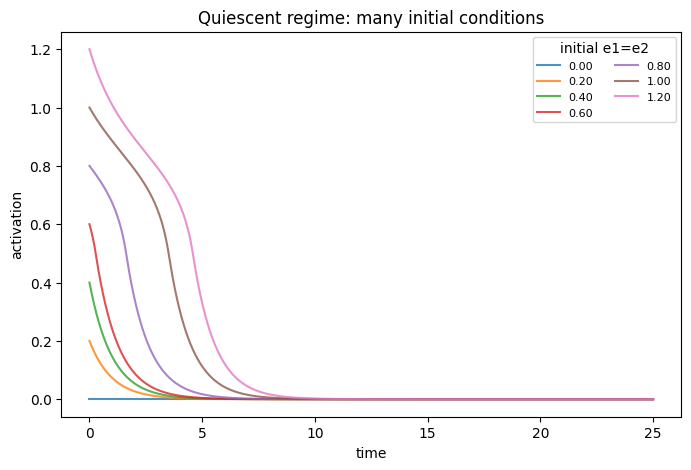

In [ ]:

def plot_many_initial_conditions(params, title, grid=np.linspace(0, 1.2, 7), t=np.linspace(0, 25, 1000)):
    plt.figure(figsize=(8, 5))
    for e0 in grid:
        sol = simulate_rashevsky([e0, e0], t, params)
        plt.plot(t, sol[:, 0], alpha=0.8, label=f"{e0:.2f}")

    plt.xlabel("time")
    plt.ylabel("activation")
    plt.title(title)
    plt.legend(title="initial e1=e2", ncol=2, fontsize=8)
    plt.show()

plot_many_initial_conditions(params_persistent, "Persistent regime: many initial conditions")
plot_many_initial_conditions(params_quiescent, "Quiescent regime: many initial conditions")


## Exercise 7 — Explore the phase plane

A good way to understand the model is to inspect trajectories in the `(e1, e2)` plane.

**Task.** Plot several trajectories in phase space.

### Solution


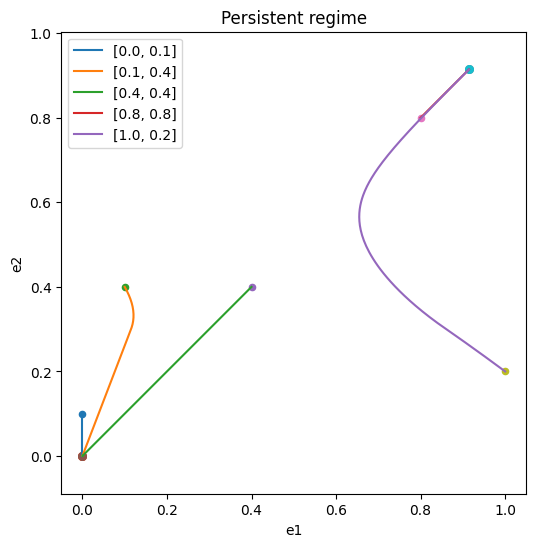

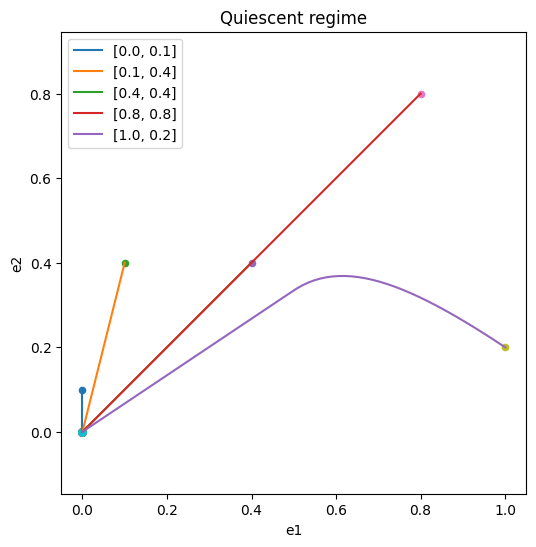

In [ ]:

def plot_phase_plane_trajectories(params, initials, t=np.linspace(0, 25, 1000), title="Phase plane trajectories"):
    plt.figure(figsize=(6, 6))
    for x0 in initials:
        sol = simulate_rashevsky(x0, t, params)
        plt.plot(sol[:, 0], sol[:, 1], label=f"{x0}")
        plt.scatter(sol[0, 0], sol[0, 1], s=20)
        plt.scatter(sol[-1, 0], sol[-1, 1], s=30)

    plt.xlabel("e1")
    plt.ylabel("e2")
    plt.title(title)
    plt.legend()
    plt.axis("equal")
    plt.show()

initials = [
    [0.0, 0.1],
    [0.1, 0.4],
    [0.4, 0.4],
    [0.8, 0.8],
    [1.0, 0.2],
]

plot_phase_plane_trajectories(params_persistent, initials, title="Persistent regime")
plot_phase_plane_trajectories(params_quiescent, initials, title="Quiescent regime")


## Exercise 9 — Approximate the nullclines

The nullclines are defined by:

- `de1/dt = 0`,
- `de2/dt = 0`.

They help explain why one parameter regime can support persistent activity while another cannot.

**Task.** Approximate the nullclines numerically and plot them.

### Solution


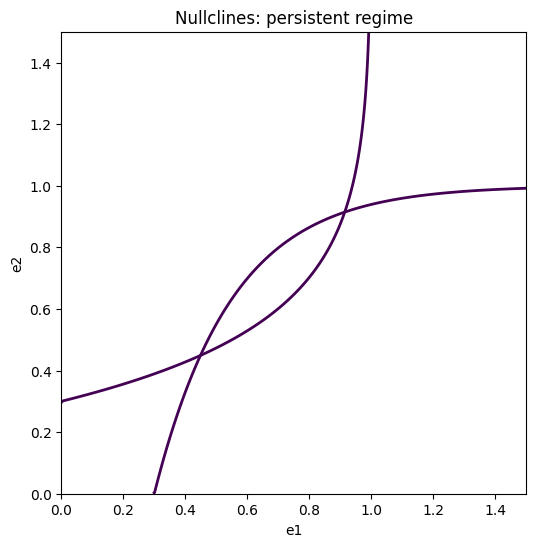

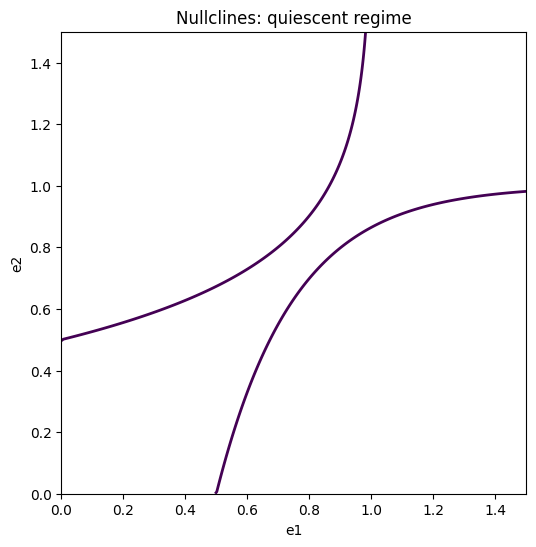

In [ ]:

def plot_nullclines(params, e1_range=(0, 1.5), e2_range=(0, 1.5), n=300, title="Nullclines"):
    e1_vals = np.linspace(*e1_range, n)
    e2_vals = np.linspace(*e2_range, n)
    E1g, E2g = np.meshgrid(e1_vals, e2_vals)

    U = np.zeros_like(E1g)
    V = np.zeros_like(E2g)

    for i in range(n):
        for j in range(n):
            de1dt, de2dt = rashevsky_rhs([E1g[i, j], E2g[i, j]], 0, params)
            U[i, j] = de1dt
            V[i, j] = de2dt

    plt.figure(figsize=(6, 6))
    plt.contour(E1g, E2g, U, levels=[0], linewidths=2)
    plt.contour(E1g, E2g, V, levels=[0], linewidths=2)
    plt.xlabel("e1")
    plt.ylabel("e2")
    plt.title(title)
    plt.xlim(e1_range)
    plt.ylim(e2_range)
    plt.show()

plot_nullclines(params_persistent, title="Nullclines: persistent regime")
plot_nullclines(params_quiescent, title="Nullclines: quiescent regime")


### Interpretation

In the persistent regime, the nullclines can intersect at a nonzero point in a way that supports sustained activity.

In the quiescent regime, the geometry tends to direct trajectories back toward zero.


## Exercise 8 — Reproduce Rashevsky's graphical analysis

We now study a simpler, more symmetric version of the model in order to reproduce the kind of graphical analysis shown in the paper.

In this section, we switch to that paper-style formulation:

$$
\dot e_1 = A\left(1-e^{-\alpha\max(0, e_2-h_2)}\right) - e_1,
$$

$$
\dot e_2 = A\left(1-e^{-\alpha\max(0, e_1-h_1)}\right) - e_2.
$$

This keeps the system symmetric:

- one shared amplitude parameter `A`,
- one shared saturation parameter `alpha`,
- thresholds `h1` and `h2`,
- no separate per-neuron parameters.

**Task.** Reproduce a paper-style phase-plane plot with explicit nullcline curves, trajectories started from the boundary of the square, and one highlighted near-threshold trajectory.

### Solution


In [ ]:
def rashevsky_paper_rhs(state, t, params):
    e1, e2 = state
    A = params["A"]
    alpha = params["alpha"]
    h1 = params["h1"]
    h2 = params["h2"]

    de1dt = A * (1.0 - np.exp(-alpha * np.maximum(0.0, e2 - h2))) - e1
    de2dt = A * (1.0 - np.exp(-alpha * np.maximum(0.0, e1 - h1))) - e2
    return [de1dt, de2dt]


def simulate_rashevsky_paper(x0, t, params):
    return odeint(rashevsky_paper_rhs, x0, t, args=(params,))


def plot_rashevsky_paper_phase_portrait(
    params,
    t=np.linspace(0, 10, 1000),
    x_max=1.5,
    highlighted_initial=(0.0, 0.9779547),
):
    x = np.linspace(0, 4, 400)
    A = params["A"]
    alpha = params["alpha"]
    h1 = params["h1"]
    h2 = params["h2"]

    e1_nullcline = A * (1.0 - np.exp(-alpha * np.maximum(0.0, x - h2)))
    e2_nullcline_input = A * (1.0 - np.exp(-alpha * np.maximum(0.0, x - h1)))

    plt.figure(figsize=(7, 7))
    plt.plot(x, e1_nullcline, linewidth=2, label=r"$\dot e_1 = 0$")
    plt.plot(e2_nullcline_input, x, linestyle="--", linewidth=2, label=r"$\dot e_2 = 0$")

    c0 = np.arange(0, x_max + 1e-9, 0.25)

    for e0 in c0:
        for x0 in ([e0, 0.0], [e0, x_max], [0.0, e0], [x_max, e0]):
            sol = simulate_rashevsky_paper(x0, t, params)
            plt.plot(sol[:, 0], sol[:, 1], color="black", alpha=0.55, linewidth=1)

    sol_highlight = simulate_rashevsky_paper(highlighted_initial, t, params)
    plt.plot(
        sol_highlight[:, 0],
        sol_highlight[:, 1],
        linestyle=":",
        linewidth=2.5,
        color="tab:red",
        label=f"highlighted trajectory: {highlighted_initial}",
    )

    plt.xlim(0, x_max)
    plt.ylim(0, x_max)
    plt.xlabel("e1")
    plt.ylabel("e2")
    plt.title("Paper-style phase portrait for the symmetric Rashevsky model")
    plt.legend()
    plt.grid(alpha=0.2)
    plt.show()


In [ ]:
params_paper = {
    "A": 1.0,
    "alpha": 4.0,
    "h1": 0.3,
    "h2": 0.3,
}

plot_rashevsky_paper_phase_portrait(params_paper)


### Exploration questions

1. What happens to the phase portrait if you increase or decrease `A`?
2. How do the nullclines and trajectories change when you raise `h1` and `h2`?
3. For which values of `alpha` does the nonzero active state become easier or harder to sustain?

The main point of this section is to connect the notebook to the graphical style of analysis used in Rashevsky's paper.


## Exercise 10 — Add a PI-style complementary second equation

Now we extend the model using the simpler modification suggested by the PI.

The idea is to keep the first equation excitatory, but to replace the second excitatory term by its **complement**.

If

$$
E(e_1; \alpha, h) = 1 - e^{-\alpha \max(0, e_1 - h)},
$$

then the modified second drive is

$$
1 - E(e_1; \alpha, h).
$$

We also divide the last component of the second equation by a factor `delta > 0`, so that the decay of `e2` can be slowed down or sped up.

We then use:

$$
\dot e_1 = A E(e_2; \alpha, h) - e_1
$$

$$
\dot e_2 = A \left(1 - E(e_1; \alpha, h)\right) - \frac{e_2}{\delta}
$$

**Task.** Implement this modified model.

### Solution


In [ ]:

def rashevsky_inhibitory_rhs(state, t, params):
    e1, e2 = state

    E1 = excitation(e1, alpha=params["alpha"], h=params["h"])
    E2 = excitation(e2, alpha=params["alpha"], h=params["h"])

    de1dt = params["A"] * E2 - e1
    de2dt = params["A"] * (1.0 - E1) - e2 / params["delta"]
    return [de1dt, de2dt]


def simulate_inhibitory(x0, t, params):
    return odeint(rashevsky_inhibitory_rhs, x0, t, args=(params,))


## Exercise 11 — Change the stabilization timescale

**Task.** Run the modified system for one parameter setting and inspect how the trajectories settle over time.

The main quantity of interest is the decay factor `delta`, which changes how quickly `e2` relaxes.

### Solution


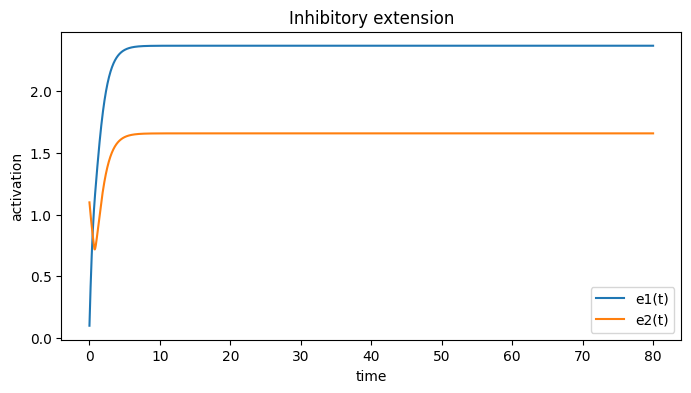

In [ ]:

params_inhibitory = {
    "A": 1.2,
    "alpha": 3.0,
    "h": 0.2,
    "delta": 1.5,
}

t_long = np.linspace(0, 80, 3000)
x0 = [0.1, 1.1]

sol_inh = simulate_inhibitory(x0, t_long, params_inhibitory)

plt.figure(figsize=(8, 4))
plt.plot(t_long, sol_inh[:, 0], label="e1(t)")
plt.plot(t_long, sol_inh[:, 1], label="e2(t)")
plt.xlabel("time")
plt.ylabel("activation")
plt.title("Complementary second-equation extension")
plt.legend()
plt.show()


When `delta` is larger, the second component decays more slowly, so the system may take longer to settle. In phase space, this can produce wider curved trajectories, or even spiral-like approaches to equilibrium.

The important point here is not to prove the existence of a true limit cycle, but to see how a change in timescale affects the way the system stabilizes.


## Exercise 12 — Compare a few values of `delta`

**Task.** Compare a small number of values of `delta` and inspect how the phase-plane trajectory changes.

### Solution


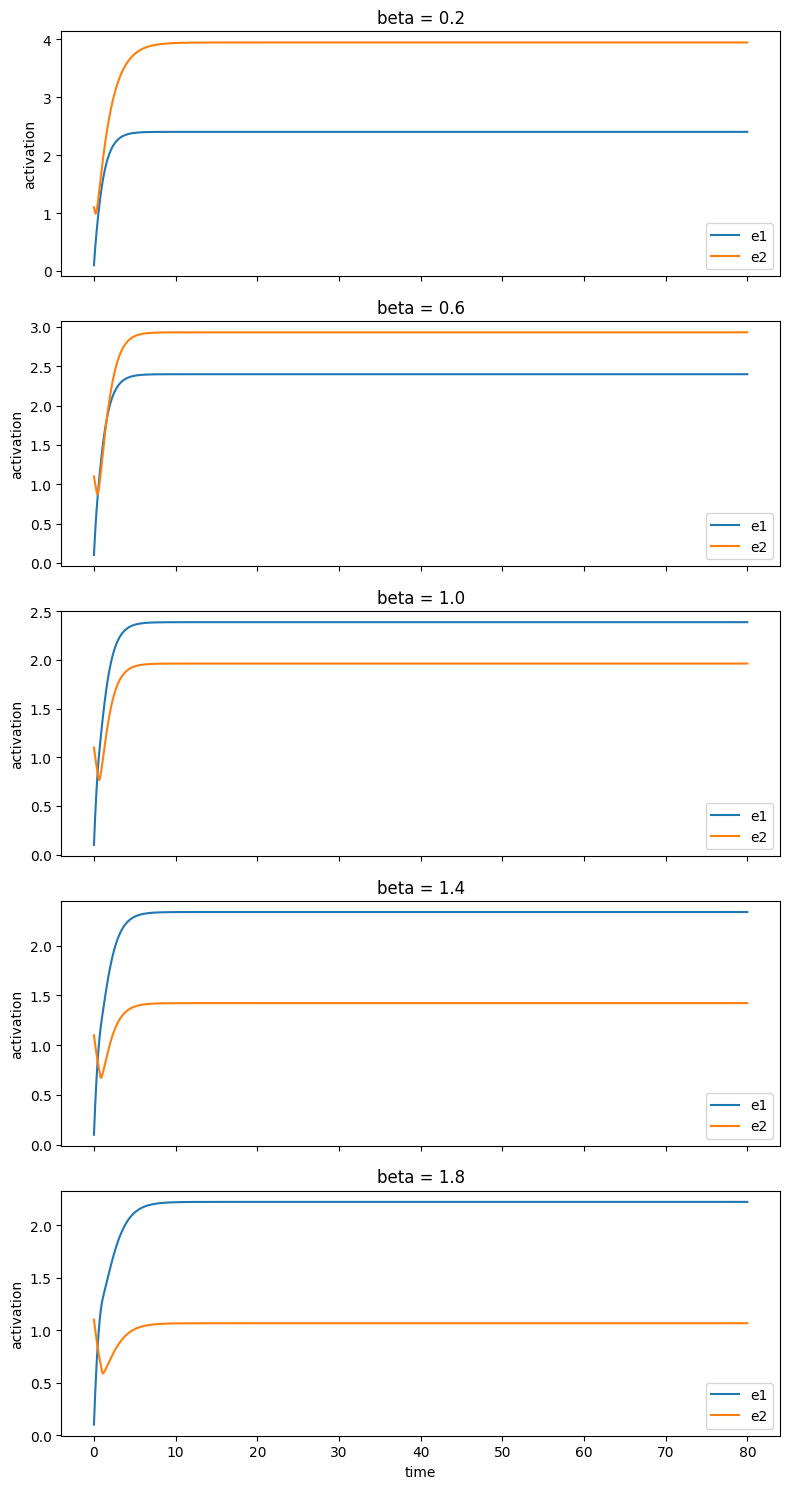

In [ ]:

deltas = [0.75, 1.5, 3.0]

fig, axes = plt.subplots(1, len(deltas), figsize=(5 * len(deltas), 4), sharey=True)

for ax, delta in zip(axes, deltas):
    params = params_inhibitory.copy()
    params["delta"] = delta
    sol = simulate_inhibitory([0.1, 1.1], t_long, params)
    ax.plot(sol[:, 0], sol[:, 1], color="tab:blue")
    ax.scatter(sol[0, 0], sol[0, 1], s=20, color="tab:green", label="start")
    ax.scatter(sol[-1, 0], sol[-1, 1], s=25, color="tab:red", label="end")
    ax.set_title(f"delta = {delta}")
    ax.set_xlabel("e1")
    ax.set_ylabel("e2")
    ax.legend()
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()
